# Maintenance prédictive — Condition de la valve hydraulique

**Support de restitution** — projet de Machine Learning.

> *Contexte.* Data Scientist dans une entreprise industrielle, on met en place un
> système de **maintenance prédictive** et on cherche à comprendre pourquoi la
> **condition de la valve** d'un cycle de production est parfois non optimale.

**Objectif.** Construire un modèle qui prédit, pour chaque cycle, si la condition
de la valve est **optimale (100 %)** ou **non optimale** (90 / 80 / 73 %).

## Sommaire
1. Chargement et exploration des données
2. Préparation des données (extraction de features)
3. Modélisation et comparaison de modèles
4. Évaluation sur l'échantillon de test final
5. Analyse des causes (variables influentes)
6. Limites et perspectives

In [1]:
import sys
from pathlib import Path

# Racine du projet (parent du dossier notebooks/).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from hydraulic_valve import config, data, features, train, evaluate, eda

pd.set_option("display.max_columns", 60)
print("Racine projet :", config.PROJECT_ROOT)
print("Capteurs utilisés :", dict(config.SENSORS))

Racine projet : C:\Users\ahlam\Desktop\Projet_ML
Capteurs utilisés : {'PS2': 100.0, 'FS1': 10.0}


## 1. Chargement et exploration des données

Le jeu de données provient d'un banc d'essai hydraulique (UCI / ZeMA). Conformément
à l'énoncé, on utilise uniquement **3 fichiers** (1 ligne = 1 cycle de 60 s) :

| Fichier | Grandeur | Échantillonnage | Points/cycle |
|---|---|---|---|
| `PS2` | Pression (bar) | 100 Hz | 6000 |
| `FS1` | Débit volumique (L/min) | 10 Hz | 600 |
| `profile` | Cibles (5 colonnes) | — | colonne 2 = **valve** |

La cible binaire : **1 = valve optimale (100 %)**, **0 = non optimale**.

In [2]:
profile = data.load_profile()
y = data.get_target()
valve = profile[:, config.VALVE_COLUMN]

vc = pd.Series(valve).value_counts().sort_index().rename_axis("valve (%)").to_frame("nb cycles")
print("Répartition des 4 niveaux de condition de valve :")
display(vc)
print(f"\nCible binaire -> optimale(1) = {int(y.sum())} | "
      f"non optimale(0) = {int((y==0).sum())} | total = {len(y)}")

Répartition des 4 niveaux de condition de valve :


,nb cycles
valve (%),
73.0,360
80.0,360
90.0,360
100.0,1125



Cible binaire -> optimale(1) = 1125 | non optimale(0) = 1080 | total = 2205


In [3]:
# Dimensions des signaux capteurs
sensors = data.load_raw_sensors()
for name, arr in sensors.items():
    print(f"{name:4} : {arr.shape[0]} cycles x {arr.shape[1]} points  ({config.SENSORS[name]:.0f} Hz)")

PS2  : 2205 cycles x 6000 points  (100 Hz)
FS1  : 2205 cycles x 600 points  (10 Hz)


### Split imposé : 2000 cycles d'entraînement / 205 de test

Le découpage est **séquentiel** (et non aléatoire), imposé par l'énoncé. On note
que la répartition des classes diffère entre train et test : on s'assurera donc
de ne pas faire fuiter d'information du test vers l'entraînement.

In [4]:
tr, te = data.train_test_indices(len(y))
dist = pd.DataFrame({
    "Train (2000)": [int((y[tr]==0).sum()), int((y[tr]==1).sum())],
    "Test (205)":   [int((y[te]==0).sum()), int((y[te]==1).sum())],
}, index=["Non optimale (0)", "Optimale (1)"])
dist["Train %"] = (100*dist["Train (2000)"]/dist["Train (2000)"].sum()).round(1)
dist["Test %"]  = (100*dist["Test (205)"]/dist["Test (205)"].sum()).round(1)
display(dist)

,Train (2000),Test (205),Train %,Test %
Non optimale (0),948,132,47.4,64.4
Optimale (1),1052,73,52.6,35.6


>> Figures EDA sauvegardées dans : C:\Users\ahlam\Desktop\Projet_ML\reports\figures


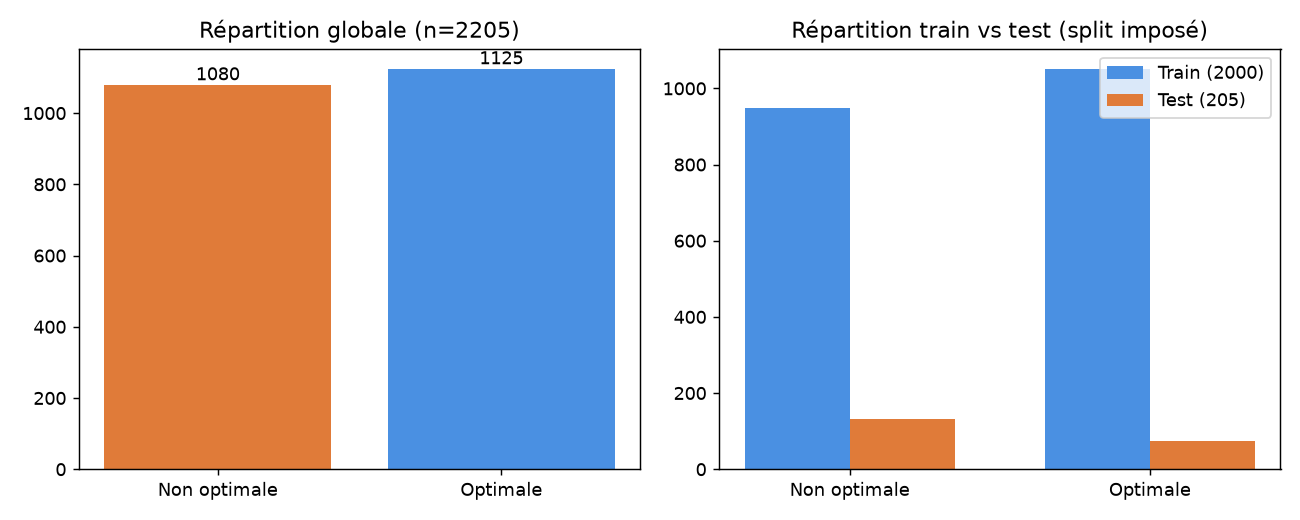

In [5]:
# Génération des figures d'exploration
eda.run_eda()
display(Image(filename=str(config.FIGURES_DIR / "eda_target_distribution.png")))

Visualisons un **cycle optimal** et un **cycle non optimal** sur les signaux bruts.
Sur un cycle défaillant, le **débit FS1 s'effondre** après ~30 s et la **pression
PS2 reste haute** : la valve ne commute pas correctement. C'est précisément ce
comportement que nos features vont capturer.

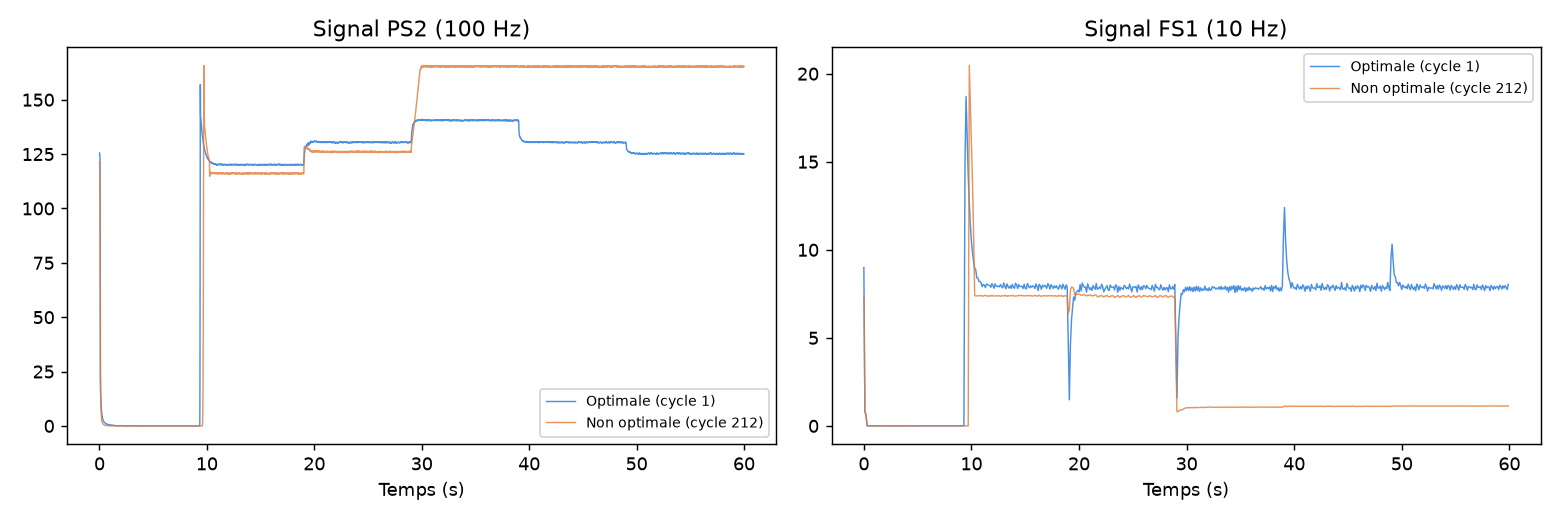

In [6]:
display(Image(filename=str(config.FIGURES_DIR / "eda_example_signals.png")))

## 2. Préparation des données — extraction de features

Plutôt que d'alimenter le modèle avec des milliers de points bruts (coûteux et
bruité), on résume **chaque cycle** par un ensemble de descripteurs, calculés de
façon vectorisée et **identique à l'entraînement et à l'inférence** :

- **Domaine temporel** : moyenne, écart-type, min/max, étendue, quantiles, IQR,
  RMS, déviation absolue moyenne, variation moyenne, **asymétrie (skew)**,
  **aplatissement (kurtosis)**, pente de tendance.
- **Domaine fréquentiel (FFT)** : centroïde spectral, fréquence dominante,
  énergie totale, ratios d'énergie par bandes.

Soit **48 features** (24 par capteur × 2 capteurs).

In [7]:
X = features.build_feature_matrix(sensors)
print("Matrice de features :", X.shape)
display(X.iloc[:5, :8])

Matrice de features : (2205, 48)


,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_range,PS2_median,PS2_q10,PS2_q25
0,109.466919,47.110580,0.0,156.990005,156.990005,129.364998,0.0,120.190002
1,109.354897,47.041687,0.0,157.559998,157.559998,129.385002,0.0,120.129997
2,109.158852,46.988144,0.0,156.970001,156.970001,129.324997,0.0,120.040001
3,109.064812,46.968304,0.0,156.440002,156.440002,128.865005,0.0,119.959999
4,108.931435,46.871037,0.0,158.130005,158.130005,129.000000,0.0,119.837498


## 3. Modélisation et comparaison de modèles

On compare trois modèles par **validation croisée stratifiée (5 plis)**, calculée
**uniquement sur les 2000 cycles d'entraînement** :

- **Régression logistique** (référence / baseline, avec standardisation) ;
- **Random Forest** ;
- **Histogram Gradient Boosting**.

Le meilleur (ROC-AUC moyen) est ré-entraîné sur les 2000 cycles puis sauvegardé.

In [8]:
meta = train.train()
cv_df = (pd.DataFrame(meta["cv_results"]).T
         [["accuracy", "balanced_accuracy", "f1_macro", "roc_auc"]]
         .round(4))
print("\nValidation croisée (5 plis) — moyennes :")
display(cv_df)
print("Modèle retenu :", meta["model_name"])

>> Construction du jeu de features...


   Features : 48 | Train : 2000 cycles | Test : 205 cycles
>> Comparaison des modèles (validation croisée 5 plis)...


   logreg         acc=0.9825  bal_acc=0.9820  f1=0.9824  auc=0.9946
   random_forest  acc=0.9970  bal_acc=0.9971  f1=0.9970  auc=1.0000
   hist_gb        acc=0.9980  bal_acc=0.9980  f1=0.9980  auc=1.0000
>> Meilleur modèle : random_forest


>> Modèle sauvegardé : C:\Users\ahlam\Desktop\Projet_ML\models\valve_model.joblib

Validation croisée (5 plis) — moyennes :


,accuracy,balanced_accuracy,f1_macro,roc_auc
logreg,0.9825,0.9820,0.9824,0.9946
random_forest,0.9970,0.9971,0.9970,1.0000
hist_gb,0.9980,0.9980,0.9980,1.0000


Modèle retenu : random_forest


## 4. Évaluation sur l'échantillon de test final

On évalue le modèle retenu sur les **205 derniers cycles**, jamais vus pendant
l'entraînement ni la sélection.

In [9]:
metrics = evaluate.evaluate()
print()
rep = pd.DataFrame(metrics["classification_report"]).T.round(3)
display(rep)

>> Test final (205 cycles) — modèle : random_forest
   Accuracy           : 1.0000
   Balanced accuracy  : 1.0000
   ROC-AUC            : 1.0000


>> Métriques et figures sauvegardées dans : C:\Users\ahlam\Desktop\Projet_ML\reports



,precision,recall,f1-score,support
Non optimale,1.0,1.0,1.0,132.0
Optimale,1.0,1.0,1.0,73.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,205.0
weighted avg,1.0,1.0,1.0,205.0


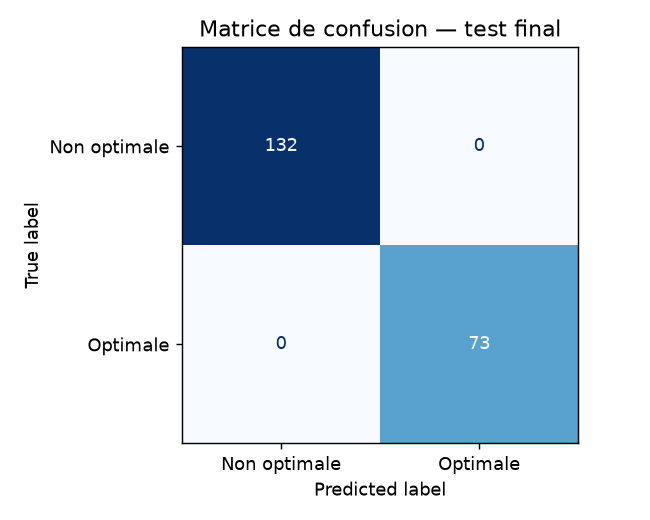

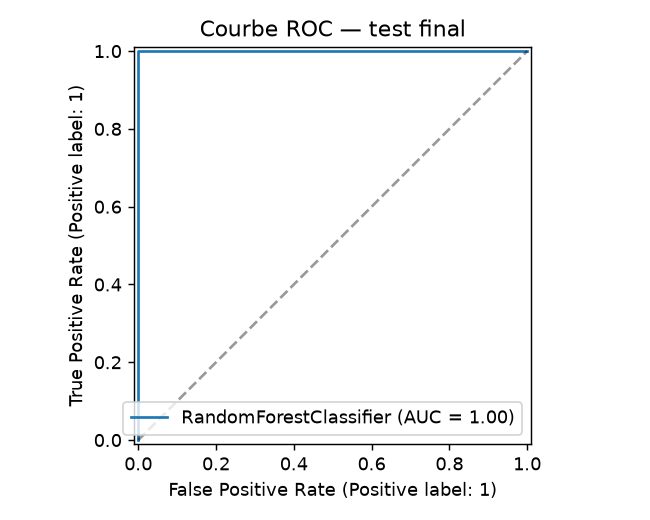

In [10]:
display(Image(filename=str(config.FIGURES_DIR / "confusion_matrix.png")))
display(Image(filename=str(config.FIGURES_DIR / "roc_curve.png")))

**Résultat : classification parfaite (100 %) sur le test final.** Ce résultat est
cohérent avec la littérature : la documentation UCI classe la valve comme une
cible « facile » (classification parfaite déjà obtenue dans les travaux d'origine).

## 5. Analyse des causes — variables influentes

Pour comprendre **pourquoi** un cycle est non optimal, on regarde les variables
les plus importantes (réduction d'impureté du Random Forest). Ce sont surtout la
**forme du signal de pression PS2** (asymétrie, aplatissement) et son **contenu
spectral** : un défaut de commutation de la valve déforme l'onde de pression.

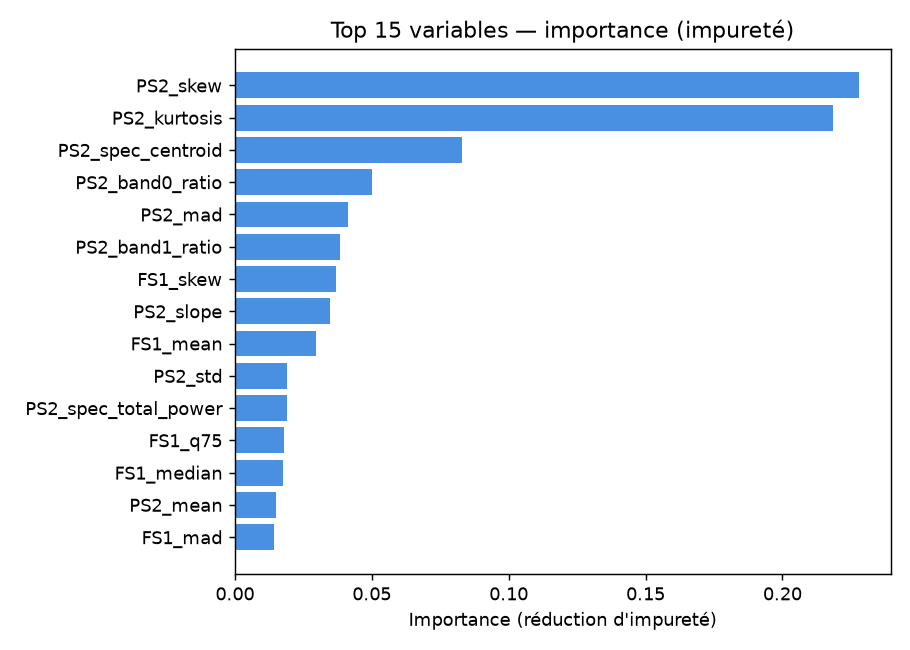

In [11]:
display(Image(filename=str(config.FIGURES_DIR / "feature_importance.png")))

**Vérification d'absence de fuite de données.** Sur seulement 2 variables, les
classes se **chevauchent** (ci-dessous) : aucune variable ne « trahit » à elle
seule la cible. La performance vient de la *combinaison* des 48 features — la
séparation parfaite est donc apprise, pas triviale.

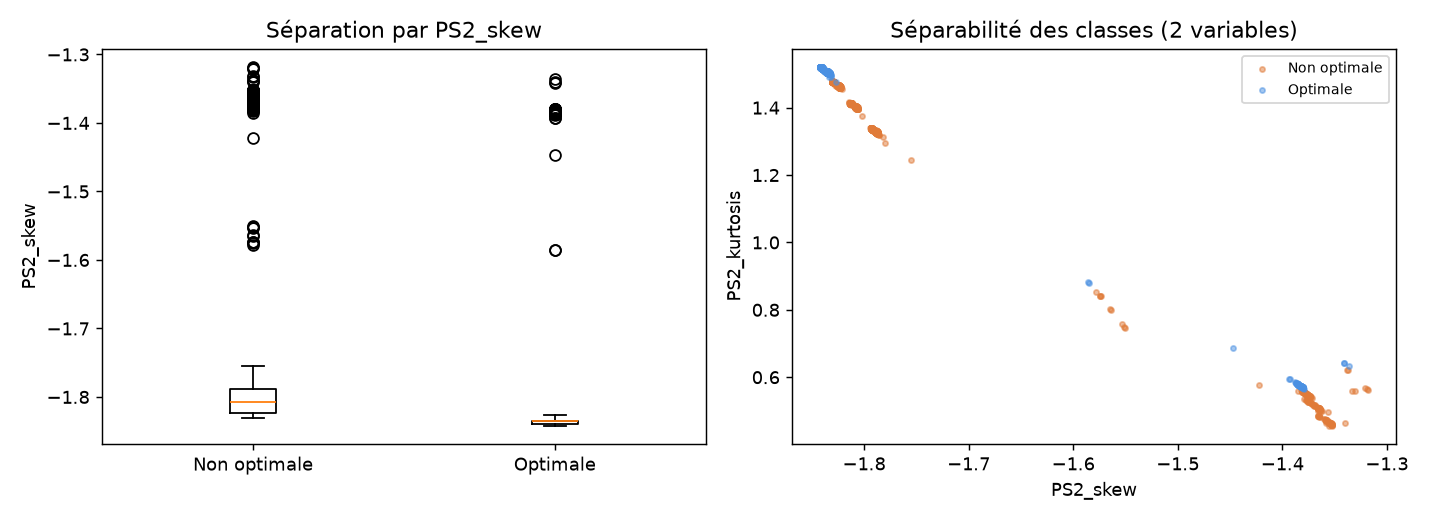

In [12]:
display(Image(filename=str(config.FIGURES_DIR / "eda_class_separation.png")))

## 6. Limites et perspectives

**Limites :**
- La performance de 100 % reflète un banc d'essai **contrôlé** ; en production
  réelle (bruit, usure, conditions variables), elle serait probablement plus
  basse. Le modèle devra être **surveillé** (dérive des données).
- Seuls **2 capteurs** (PS2, FS1) sont utilisés, comme imposé. D'autres capteurs
  aideraient pour des cibles plus difficiles (pompe, accumulateur).
- Chaque cycle est traité **indépendamment** ; le `stable flag` du profil n'est
  pas exploité (cycles éventuellement non stabilisés).

**Perspectives :**
- Approche *deep learning* (1D-CNN / LSTM) sur le signal brut pour comparaison.
- **Calibration** des probabilités et seuil orienté maintenance (privilégier le
  rappel sur la classe « non optimale »).
- Industrialisation : **API + interface web**, **Docker**, **CI/CD**, **DVC**
  (versionnage modèle + dataset) et **monitoring** (Prometheus / Grafana).

## Conclusion
Un pipeline simple (features statistiques/spectrales + Random Forest), rigoureux
sur le protocole imposé, atteint une **classification parfaite** de la condition
de la valve, tout en restant **interprétable** pour l'analyse des causes.